# CAVE embedding augmentation comparison

Compare four otherwise identical GraphTransformer models on the confidence 0.7 CAVE cohort, with separate graphs for each fold. The only training difference is the embedding choice distribution. All models are evaluated on the same **clean** held-out embeddings.

| Condition | Choices independently sampled for each node in each 10-node window |
|---|---|
| Clean | clean |
| Gray | clean + gray samples 0–3 |
| Flip | clean + flip samples 0–3 |
| Structured low | clean + structured-low samples 0–3 |

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "results" / "presynaptic").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
AUGMENTATION_DIR = ROOT / "analysis/presynaptic/cave_embedding_augmentation_conf0.7"
if str(AUGMENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(AUGMENTATION_DIR))
from cave_embedding_augmentation_comparison import (
    RESULT_ROOT, CONDITIONS, LABELS, load_summaries, load_training_curves,
    metric_deltas, plot_confusions, plot_metric_comparison,
    plot_per_class_recall, plot_training_curves,
)
RESULT_ROOT

def show_fold_figure(fig, fold):
    if fig is not None:
        title = fig._suptitle.get_text() if fig._suptitle is not None else ""
        fig.suptitle(f"Fold {fold}" + (f" — {title}" if title else ""))
        display(fig)
        plt.close(fig)


## Training progress

The loader reshuffles windows every epoch. In augmented runs, each node independently draws from its five allowed embeddings on every dataset access.

Fold 0


,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_thalamocortical,cell_precision_BasketFam,cell_precision_BipFam,cell_precision_MartFam,cell_precision_NglFam,cell_precision_pyramidal,cell_precision_thalamocortical,run,condition,fold
145,29,0.274071,0.857029,0.672851,0.633284,0.639030,0.929775,0.729348,0.898877,0.740258,...,0.621106,1.0,1.0,0.791667,0.666667,0.934932,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,clean,0
295,29,0.281077,0.853958,0.667673,0.645933,0.646089,0.930362,0.729348,0.898877,0.740258,...,0.777475,1.0,1.0,0.791667,0.666667,0.934932,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,gray,0
445,29,0.274000,0.855461,0.669116,0.653253,0.652537,0.930362,0.729348,0.898877,0.740258,...,0.777394,1.0,1.0,0.791667,0.666667,0.934932,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,flip,0
595,29,0.275124,0.858741,0.670042,0.637767,0.643462,0.929775,0.729348,0.898877,0.740258,...,0.646273,1.0,1.0,0.791667,0.666667,0.934932,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,structured_low,0


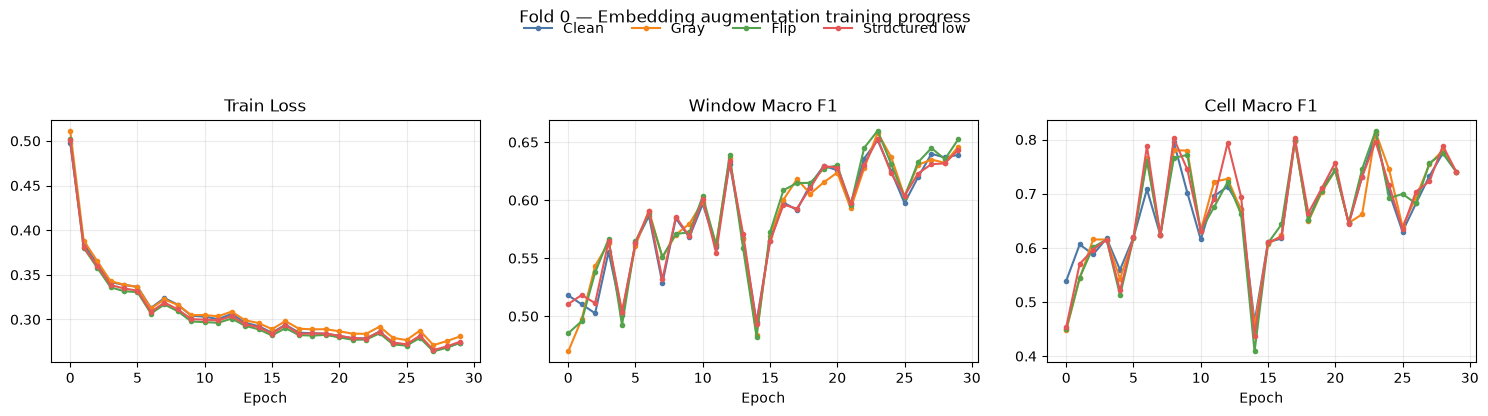

Fold 1


,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_thalamocortical,cell_precision_BasketFam,cell_precision_BipFam,cell_precision_MartFam,cell_precision_NglFam,cell_precision_pyramidal,cell_precision_thalamocortical,run,condition,fold
146,29,0.275297,0.847729,0.636165,0.717387,0.651869,0.932773,0.689822,0.755184,0.662359,...,0.869993,0.941176,1.0,0.615385,0.0,0.974545,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,clean,1
296,29,0.280213,0.843543,0.642855,0.699619,0.659152,0.927171,0.673155,0.752032,0.632471,...,0.881430,0.941176,1.0,0.600000,0.0,0.971014,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,gray,1
446,29,0.275038,0.842174,0.639769,0.704811,0.657350,0.938375,0.706488,0.756374,0.686149,...,0.880172,0.941176,1.0,0.615385,0.0,0.981685,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,flip,1
596,29,0.275907,0.844485,0.640486,0.705685,0.657238,0.941176,0.714822,0.761321,0.700268,...,0.884717,0.941176,1.0,0.648649,0.0,0.978102,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,structured_low,1


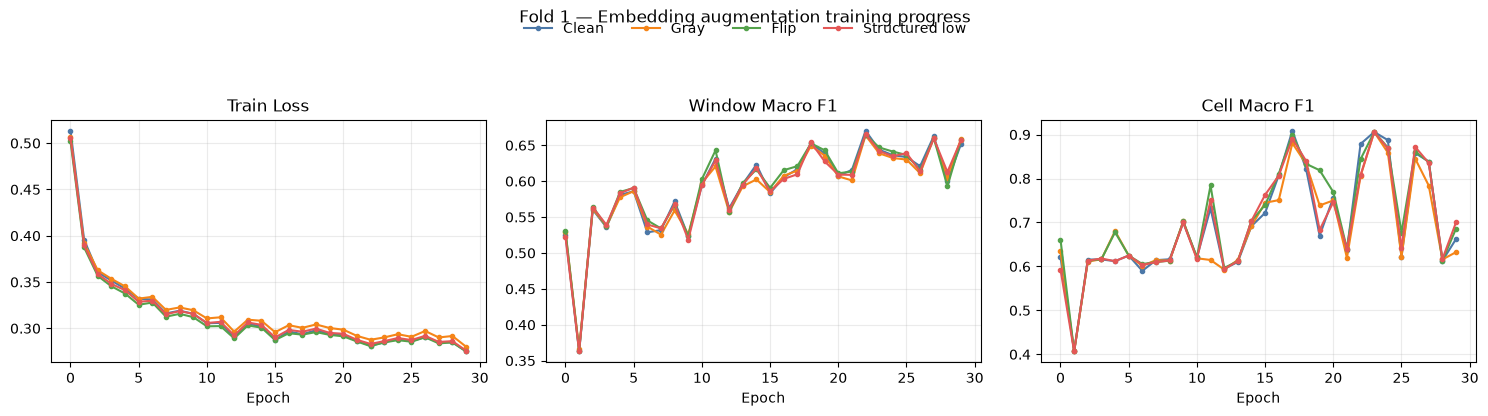

Fold 2


,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_thalamocortical,cell_precision_BasketFam,cell_precision_BipFam,cell_precision_MartFam,cell_precision_NglFam,cell_precision_pyramidal,cell_precision_thalamocortical,run,condition,fold
147,29,0.278838,0.824239,0.660832,0.654839,0.634132,0.923729,0.686897,0.732815,0.663552,...,0.501598,0.888889,0.0,0.526316,1.0,0.981685,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,clean,2
297,29,0.287924,0.824080,0.652571,0.659107,0.629696,0.926554,0.694473,0.740837,0.671078,...,0.523393,0.914286,0.0,0.552632,1.0,0.978102,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,gray,2
447,29,0.280401,0.825557,0.658333,0.652224,0.633412,0.926554,0.694473,0.740837,0.671078,...,0.515754,0.914286,0.0,0.552632,1.0,0.978102,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,flip,2
597,29,0.283035,0.828312,0.661030,0.657771,0.638140,0.923729,0.686897,0.734589,0.665133,...,0.525630,0.888889,0.0,0.540541,1.0,0.978102,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,structured_low,2


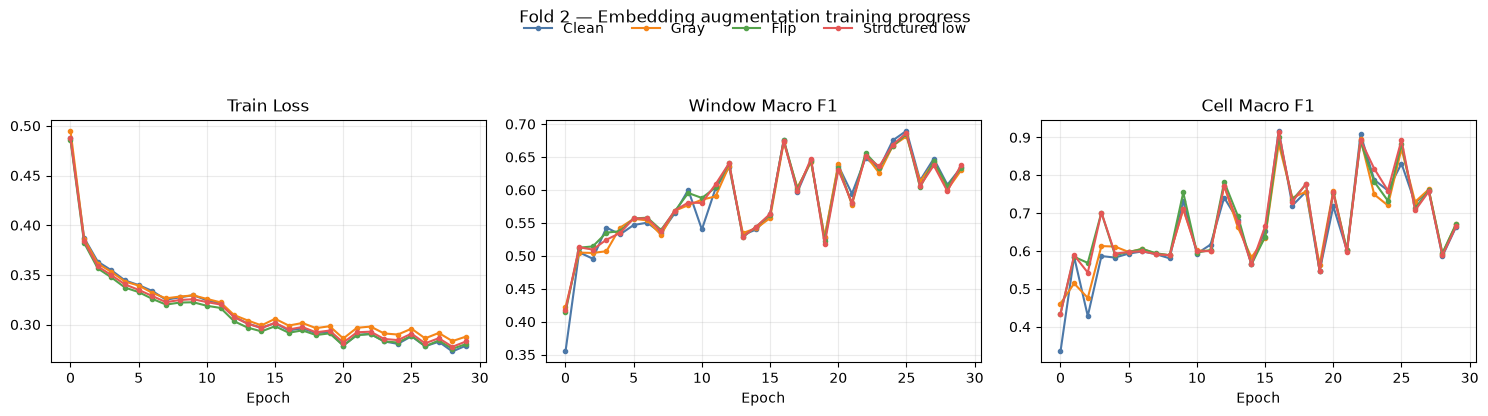

Fold 3


,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_thalamocortical,cell_precision_BasketFam,cell_precision_BipFam,cell_precision_MartFam,cell_precision_NglFam,cell_precision_pyramidal,cell_precision_thalamocortical,run,condition,fold
148,29,0.268361,0.820387,0.682800,0.693781,0.656886,0.903683,0.779488,0.759812,0.764425,...,0.908266,0.744186,0.0,0.888889,1.0,0.925795,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,clean,3
298,29,0.273580,0.823735,0.683797,0.700110,0.658223,0.903683,0.779488,0.752562,0.761617,...,0.907990,0.744186,0.0,0.842105,1.0,0.929078,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,gray,3
448,29,0.266546,0.823011,0.684261,0.703117,0.662374,0.903683,0.779488,0.762221,0.766058,...,0.913743,0.761905,0.0,0.888889,1.0,0.922535,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,flip,3
598,29,0.268125,0.818947,0.677018,0.697481,0.652293,0.900850,0.772241,0.748281,0.754713,...,0.917666,0.727273,0.0,0.833333,1.0,0.929078,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,structured_low,3


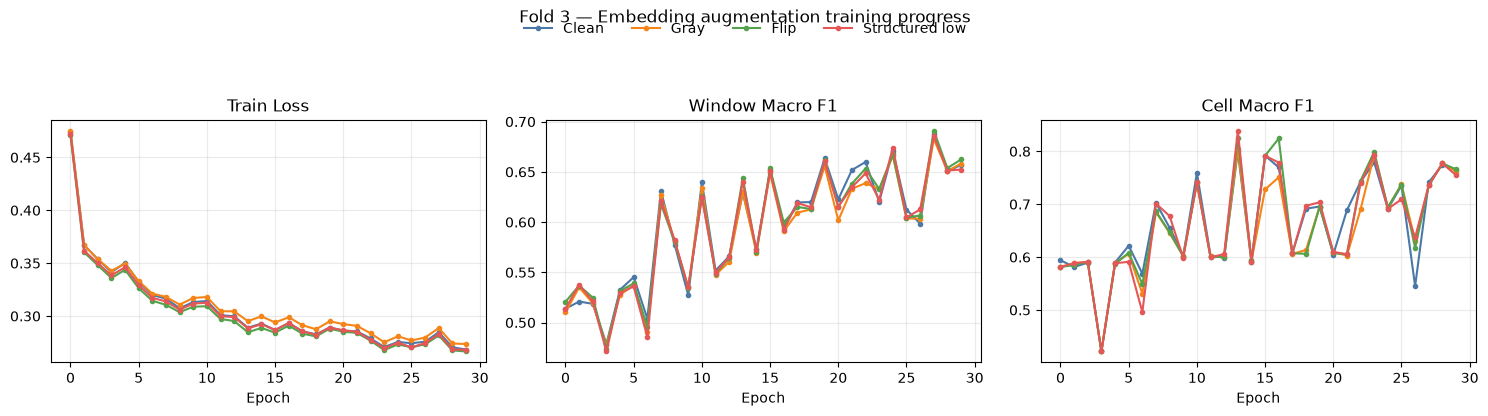

Fold 4


,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_thalamocortical,cell_precision_BasketFam,cell_precision_BipFam,cell_precision_MartFam,cell_precision_NglFam,cell_precision_pyramidal,cell_precision_thalamocortical,run,condition,fold
149,29,0.277493,0.851100,0.710608,0.699433,0.698548,0.957143,0.805138,0.971263,0.858445,...,0.737181,0.970588,1.000000,0.900000,1.0,0.956989,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,clean,4
299,29,0.286134,0.845498,0.686978,0.675219,0.673334,0.954286,0.764307,0.934459,0.806050,...,0.744621,1.000000,0.833333,0.809524,1.0,0.963899,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,gray,4
449,29,0.278715,0.847393,0.699112,0.674037,0.681214,0.957143,0.805138,0.959498,0.857238,...,0.735036,1.000000,0.900000,0.900000,1.0,0.956989,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,flip,4
599,29,0.280984,0.849285,0.709461,0.681930,0.689885,0.951429,0.788429,0.934498,0.837614,...,0.735567,1.000000,0.800000,0.850000,1.0,0.956989,1.0,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,structured_low,4


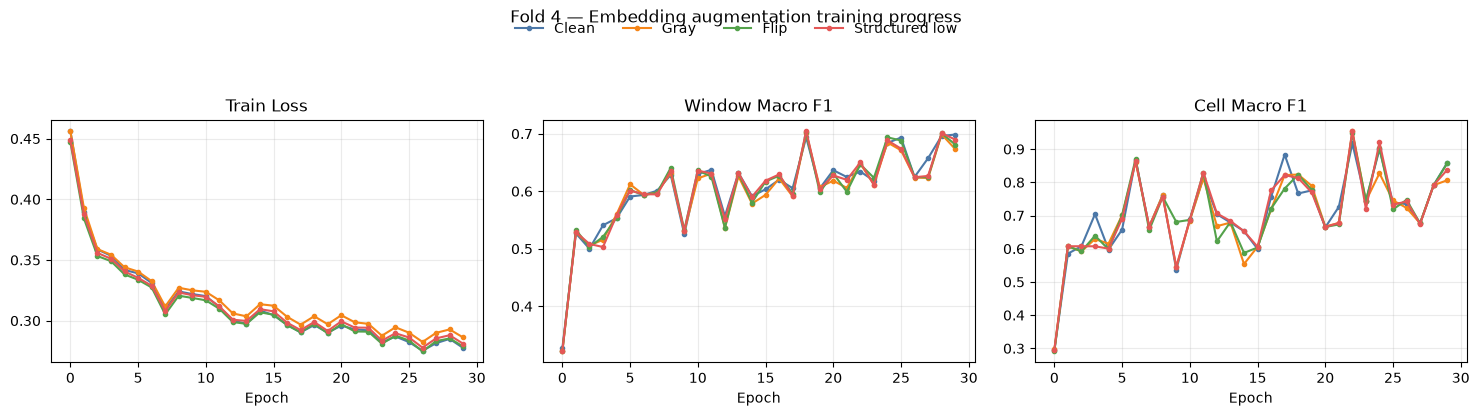

In [2]:
curves = load_training_curves()
if curves.empty:
    print("No completed epochs yet.")
else:
    curves["fold"] = curves["run"].str.extract(r"_fold(\d+)$", expand=False).astype(int)
    for fold, fold_curves in curves.groupby("fold", sort=True):
        print(f"Fold {fold}")
        latest = (fold_curves.groupby(["condition", "run"], observed=True).tail(1)
                  .sort_values("condition"))
        display(latest)
        show_fold_figure(plot_training_curves(fold_curves), fold)


## Final clean-test metrics

Cell metrics are the primary result. Window metrics show whether augmentation changes local predictions before majority voting.

Fold 0


,condition,label,run,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,fold
0,clean,Clean,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,23,0.821595,0.673318,0.645388,0.651728,0.952247,0.777040,0.934110,0.809873,0
9,gray,Gray,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,23,0.816894,0.667745,0.663852,0.658162,0.955432,0.793096,0.913966,0.813712,0
14,flip,Flip,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,23,0.818082,0.671954,0.662953,0.659796,0.955432,0.793096,0.918497,0.816246,0
15,structured_low,Structured low,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,23,0.820131,0.671999,0.649268,0.652980,0.946629,0.768096,0.915076,0.796314,0


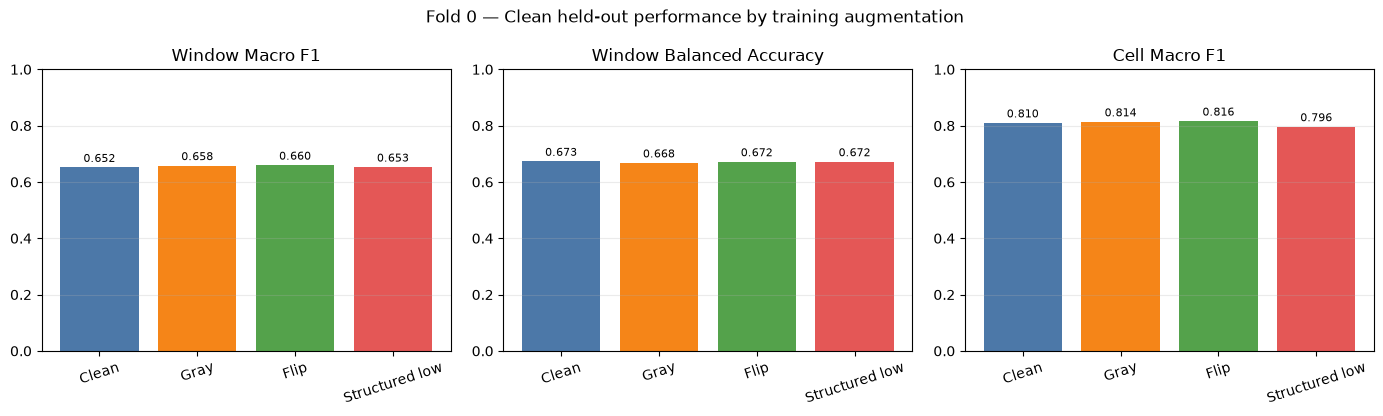

Fold 1


,condition,label,run,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,fold
1,clean,Clean,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,22,0.841393,0.669165,0.691354,0.670194,0.955182,0.851548,0.937852,0.878556,1
8,gray,Gray,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,22,0.840170,0.654453,0.692995,0.663714,0.952381,0.782877,0.928384,0.805785,1
13,flip,Flip,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,22,0.838759,0.662994,0.686907,0.664657,0.952381,0.809881,0.933002,0.844045,1
16,structured_low,Structured low,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,22,0.842277,0.662716,0.685933,0.665611,0.955182,0.782103,0.948335,0.807777,1


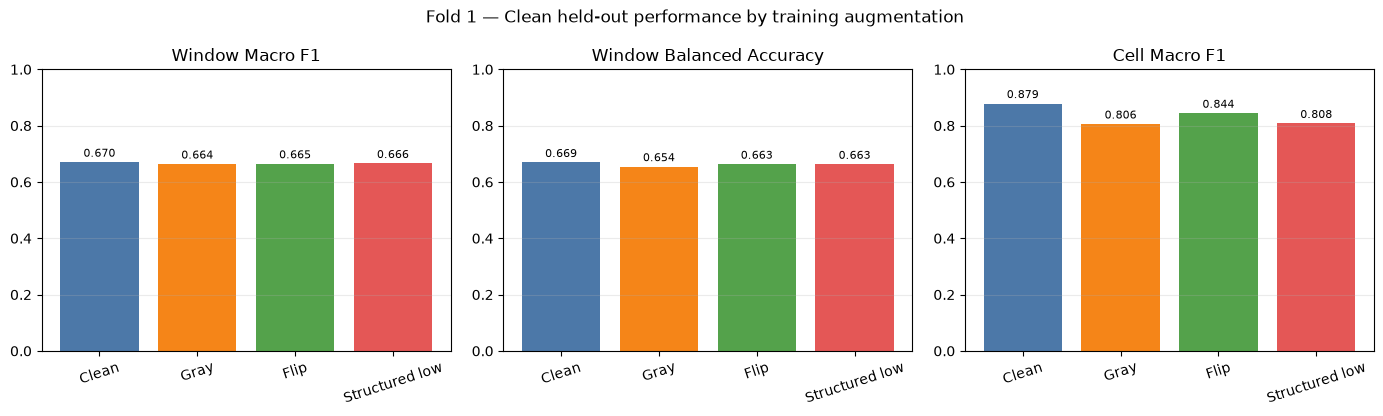

Fold 2


,condition,label,run,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,fold
2,clean,Clean,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,25,0.841203,0.717332,0.680114,0.689821,0.946328,0.806552,0.949396,0.831043,2
7,gray,Gray,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,25,0.841206,0.710680,0.673504,0.681299,0.951977,0.856991,0.955092,0.869577,2
12,flip,Flip,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,25,0.840291,0.716889,0.676021,0.684879,0.954802,0.865763,0.960647,0.883216,2
17,structured_low,Structured low,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,25,0.839964,0.716530,0.679897,0.686632,0.957627,0.874535,0.961219,0.893257,2


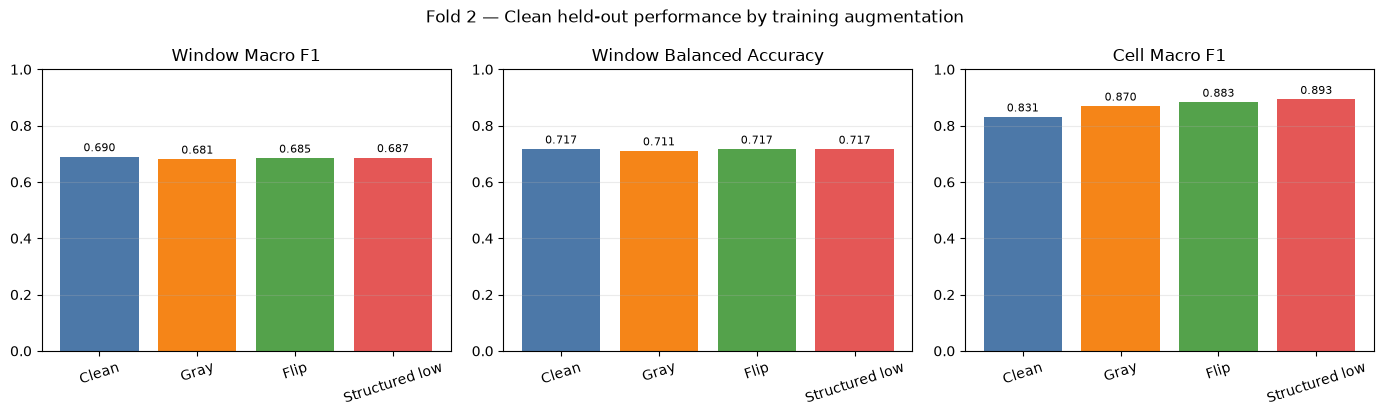

Fold 3


,condition,label,run,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,fold
3,clean,Clean,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,27,0.836962,0.669839,0.718003,0.687639,0.92068,0.727665,0.881327,0.741398,3
6,gray,Gray,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,27,0.835363,0.663345,0.720567,0.682798,0.92068,0.727336,0.915805,0.735588,3
11,flip,Flip,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,27,0.836309,0.670931,0.726611,0.690938,0.92068,0.727336,0.915805,0.735588,3
18,structured_low,Structured low,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,27,0.836538,0.668347,0.718626,0.685965,0.92068,0.727336,0.915805,0.735588,3


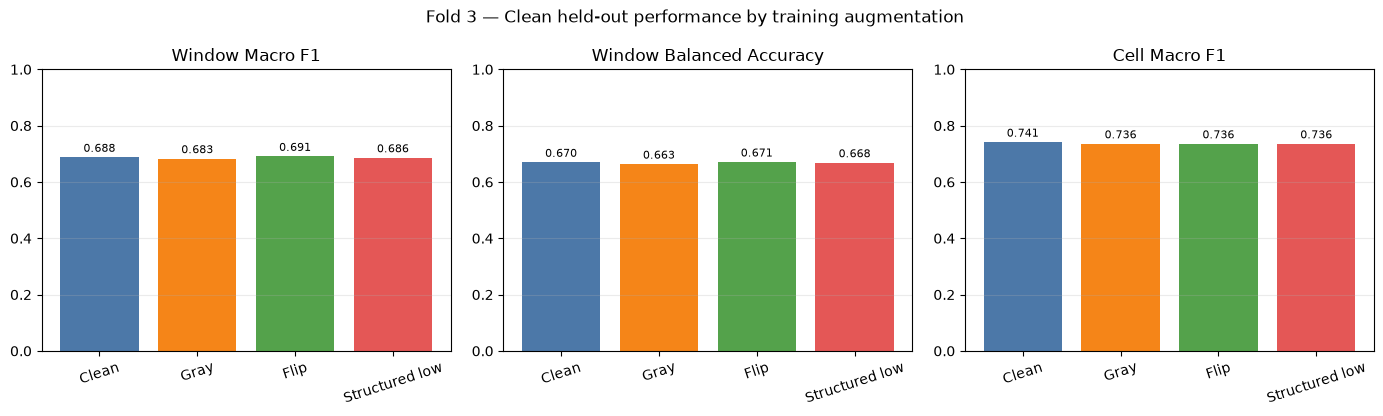

Fold 4


,condition,label,run,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,fold
4,clean,Clean,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,29,0.851100,0.710608,0.699433,0.698548,0.957143,0.805138,0.971263,0.858445,4
5,gray,Gray,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,18,0.855249,0.673966,0.785360,0.700922,0.945714,0.770886,0.935307,0.823443,4
10,flip,Flip,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,18,0.854050,0.675644,0.783403,0.702132,0.945714,0.770886,0.935307,0.823443,4
19,structured_low,Structured low,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_mixe...,18,0.854615,0.676994,0.787699,0.705112,0.942857,0.762114,0.928797,0.813177,4


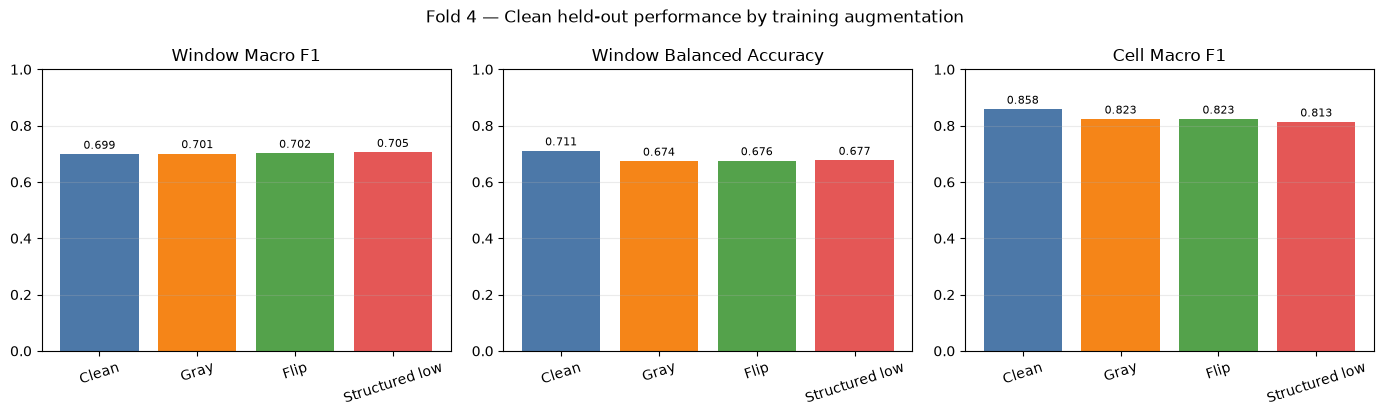

In [3]:
summary, _ = load_summaries()
payloads_by_fold = {}
if summary.empty:
    print("Final summaries appear after training finishes.")
else:
    summary["fold"] = summary["run"].str.extract(r"_fold(\d+)$", expand=False).astype(int)
    for fold, fold_summary in summary.groupby("fold", sort=True):
        # Read each run explicitly: the shared loader keys payloads only by condition.
        payloads_by_fold[fold] = {
            str(row.condition): json.loads((RESULT_ROOT / row.run / "best_metrics.json").read_text())
            for row in fold_summary.itertuples()
        }
        print(f"Fold {fold}")
        display(fold_summary)
        show_fold_figure(plot_metric_comparison(fold_summary), fold)


## Change relative to clean training

Positive values mean the augmentation-trained model outperformed the clean-only model on clean held-out data from the same fold.

In [4]:
delta_frames = []
if not summary.empty:
    for fold, fold_summary in summary.groupby("fold", sort=True):
        fold_deltas = metric_deltas(fold_summary)
        if not fold_deltas.empty:
            fold_deltas.insert(0, "fold", fold)
            delta_frames.append(fold_deltas)
deltas = pd.concat(delta_frames, ignore_index=True) if delta_frames else pd.DataFrame()
if deltas.empty:
    print("Deltas require a completed clean model and summary within the same fold.")
else:
    display(deltas)


,fold,condition,label,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1
0,0,clean,Clean,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,gray,Gray,-0.004701,-0.005574,0.018464,0.006434,0.003185,0.016056,-0.020143,0.003839
2,0,flip,Flip,-0.003514,-0.001364,0.017565,0.008068,0.003185,0.016056,-0.015612,0.006373
3,0,structured_low,Structured low,-0.001464,-0.001319,0.003880,0.001252,-0.005618,-0.008944,-0.019034,-0.013559
4,1,clean,Clean,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,1,gray,Gray,-0.001223,-0.014712,0.001641,-0.006479,-0.002801,-0.068671,-0.009468,-0.072771
6,1,flip,Flip,-0.002634,-0.006171,-0.004447,-0.005537,-0.002801,-0.041667,-0.004850,-0.034511
7,1,structured_low,Structured low,0.000883,-0.006449,-0.005421,-0.004582,0.000000,-0.069444,0.010483,-0.070779
8,2,clean,Clean,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,2,gray,Gray,0.000003,-0.006652,-0.006610,-0.008522,0.005650,0.050439,0.005696,0.038534


## Per-class recall

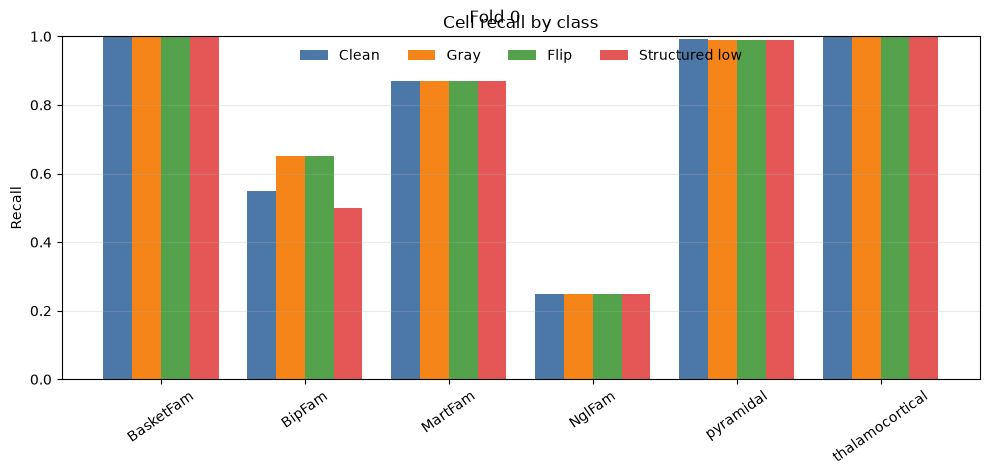

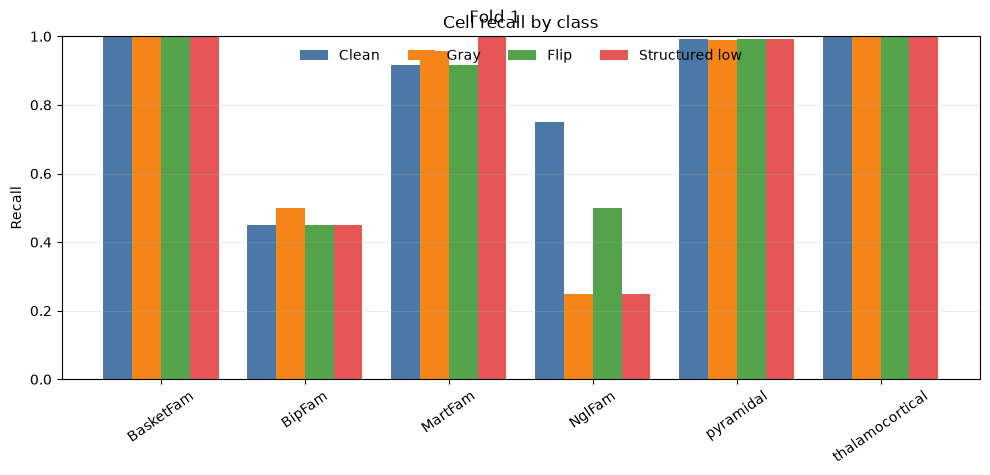

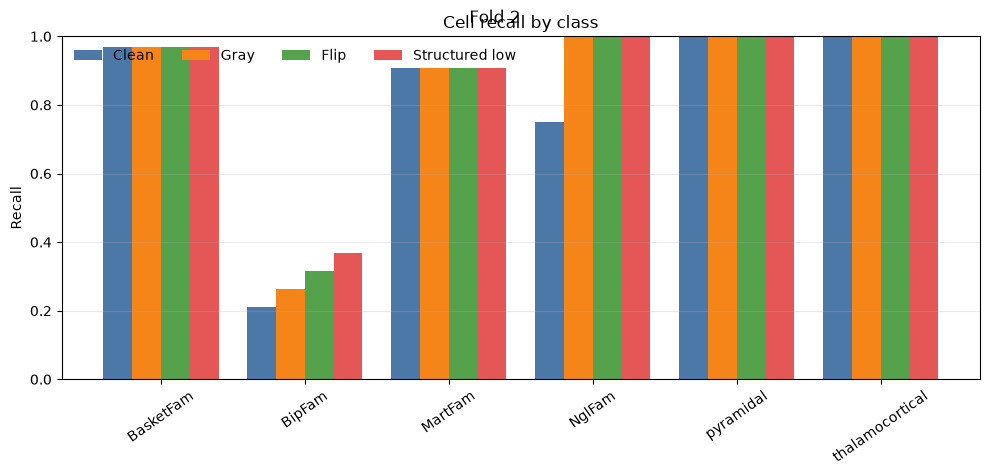

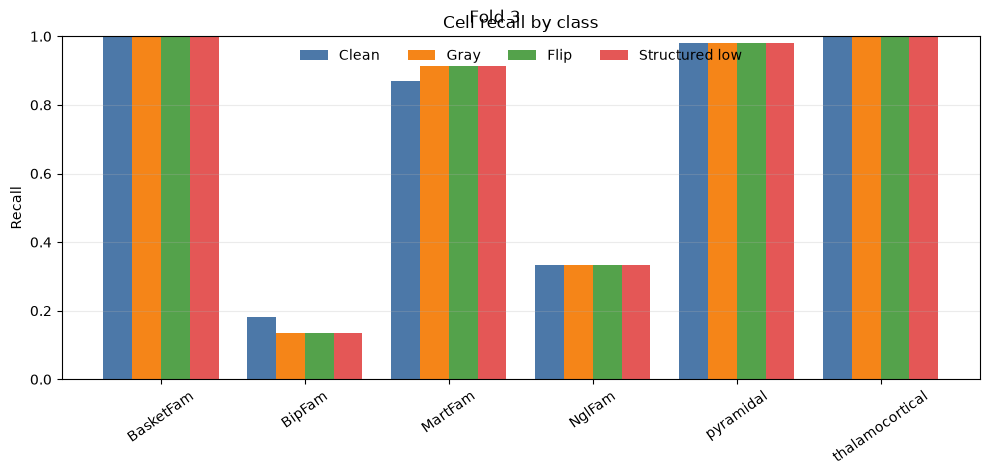

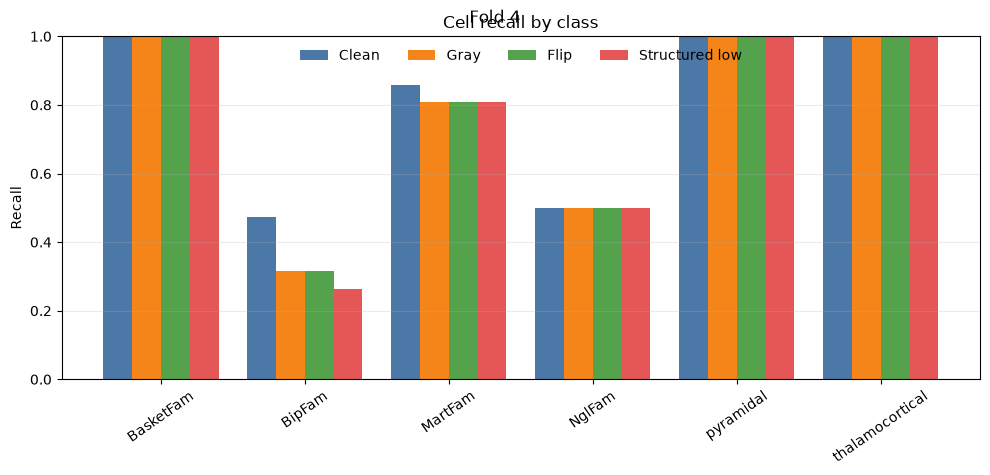

In [5]:
for fold, fold_payloads in sorted(payloads_by_fold.items()):
    show_fold_figure(plot_per_class_recall(fold_payloads), fold)


## Confusion matrices

Window-level matrices are shown in the first row and cell-level matrices in the second. Each entry reports the row-normalized fraction followed by the raw number of windows or cells in parentheses.


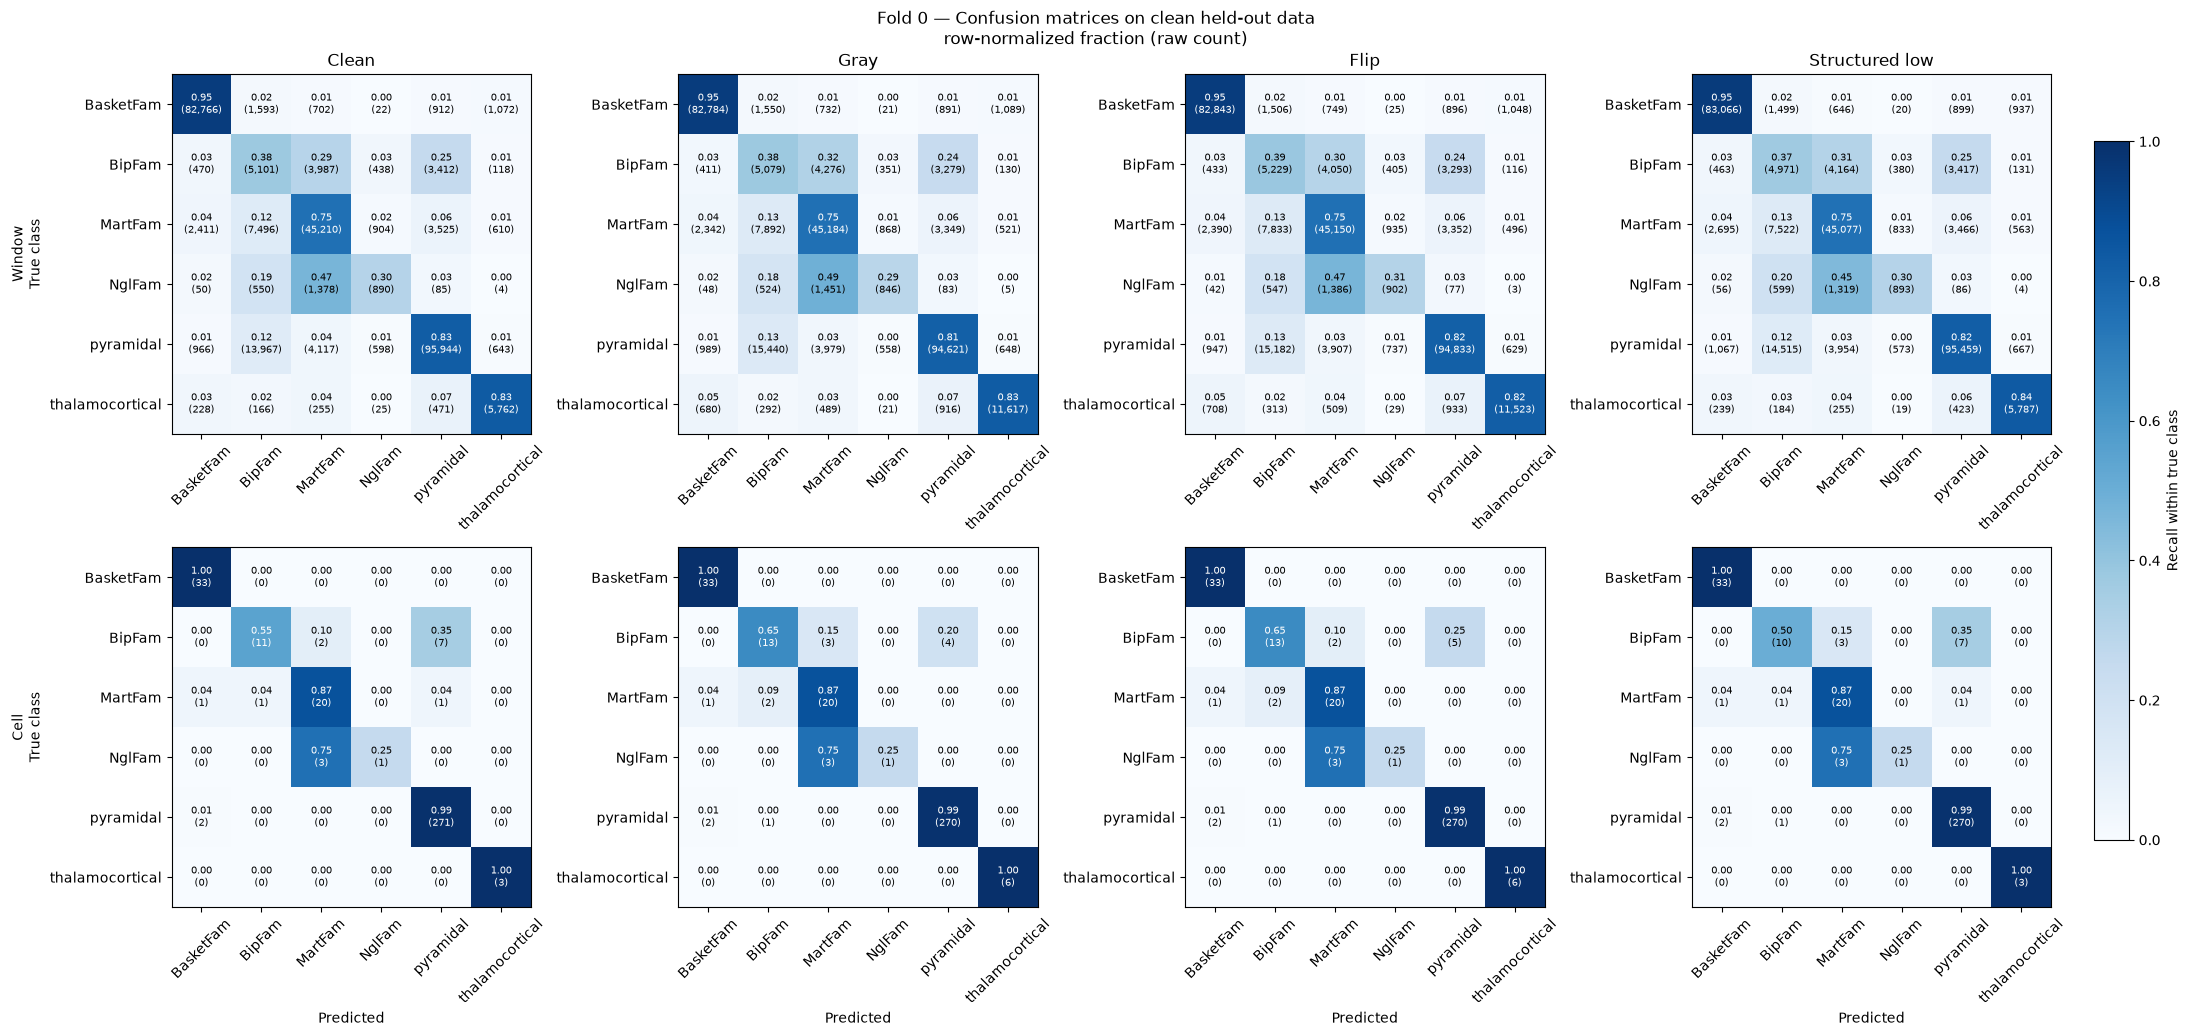

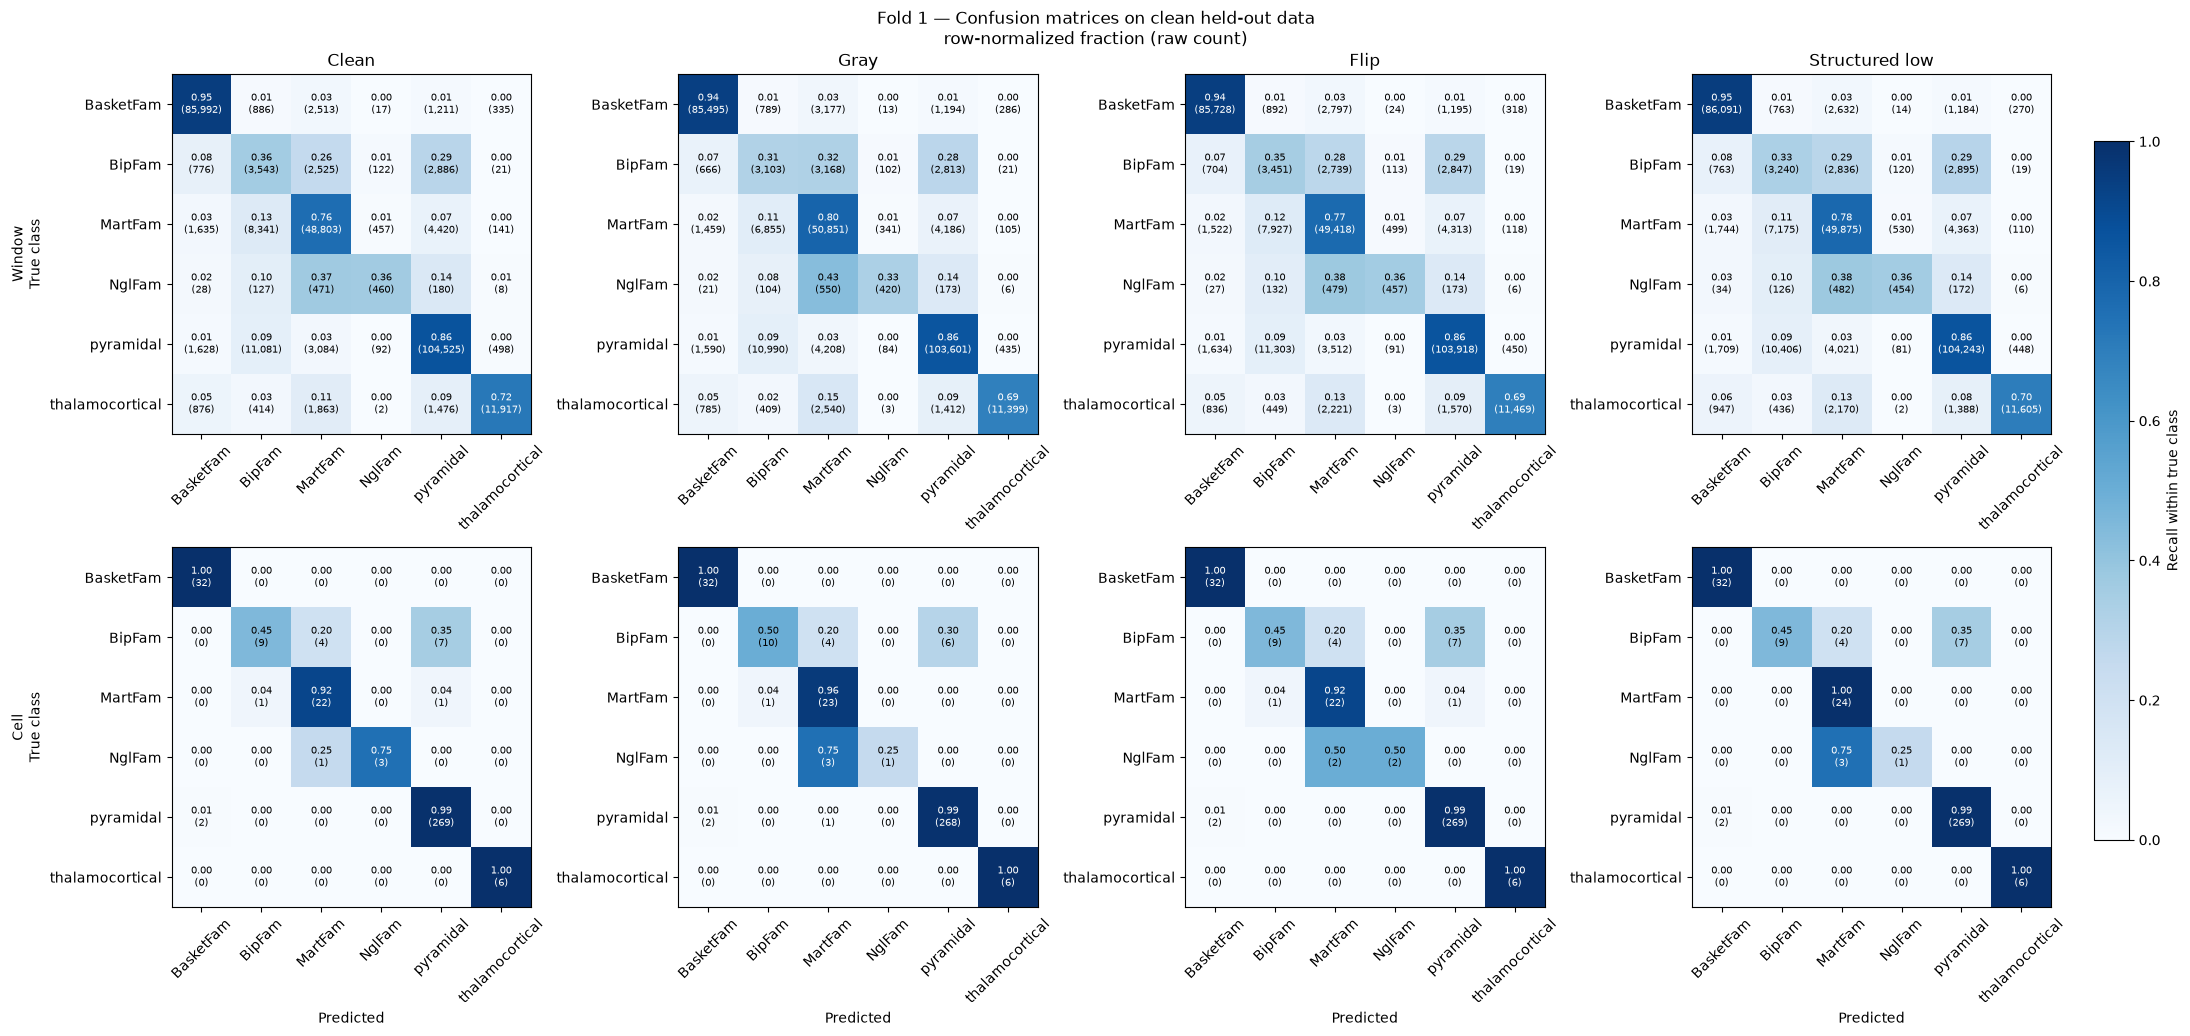

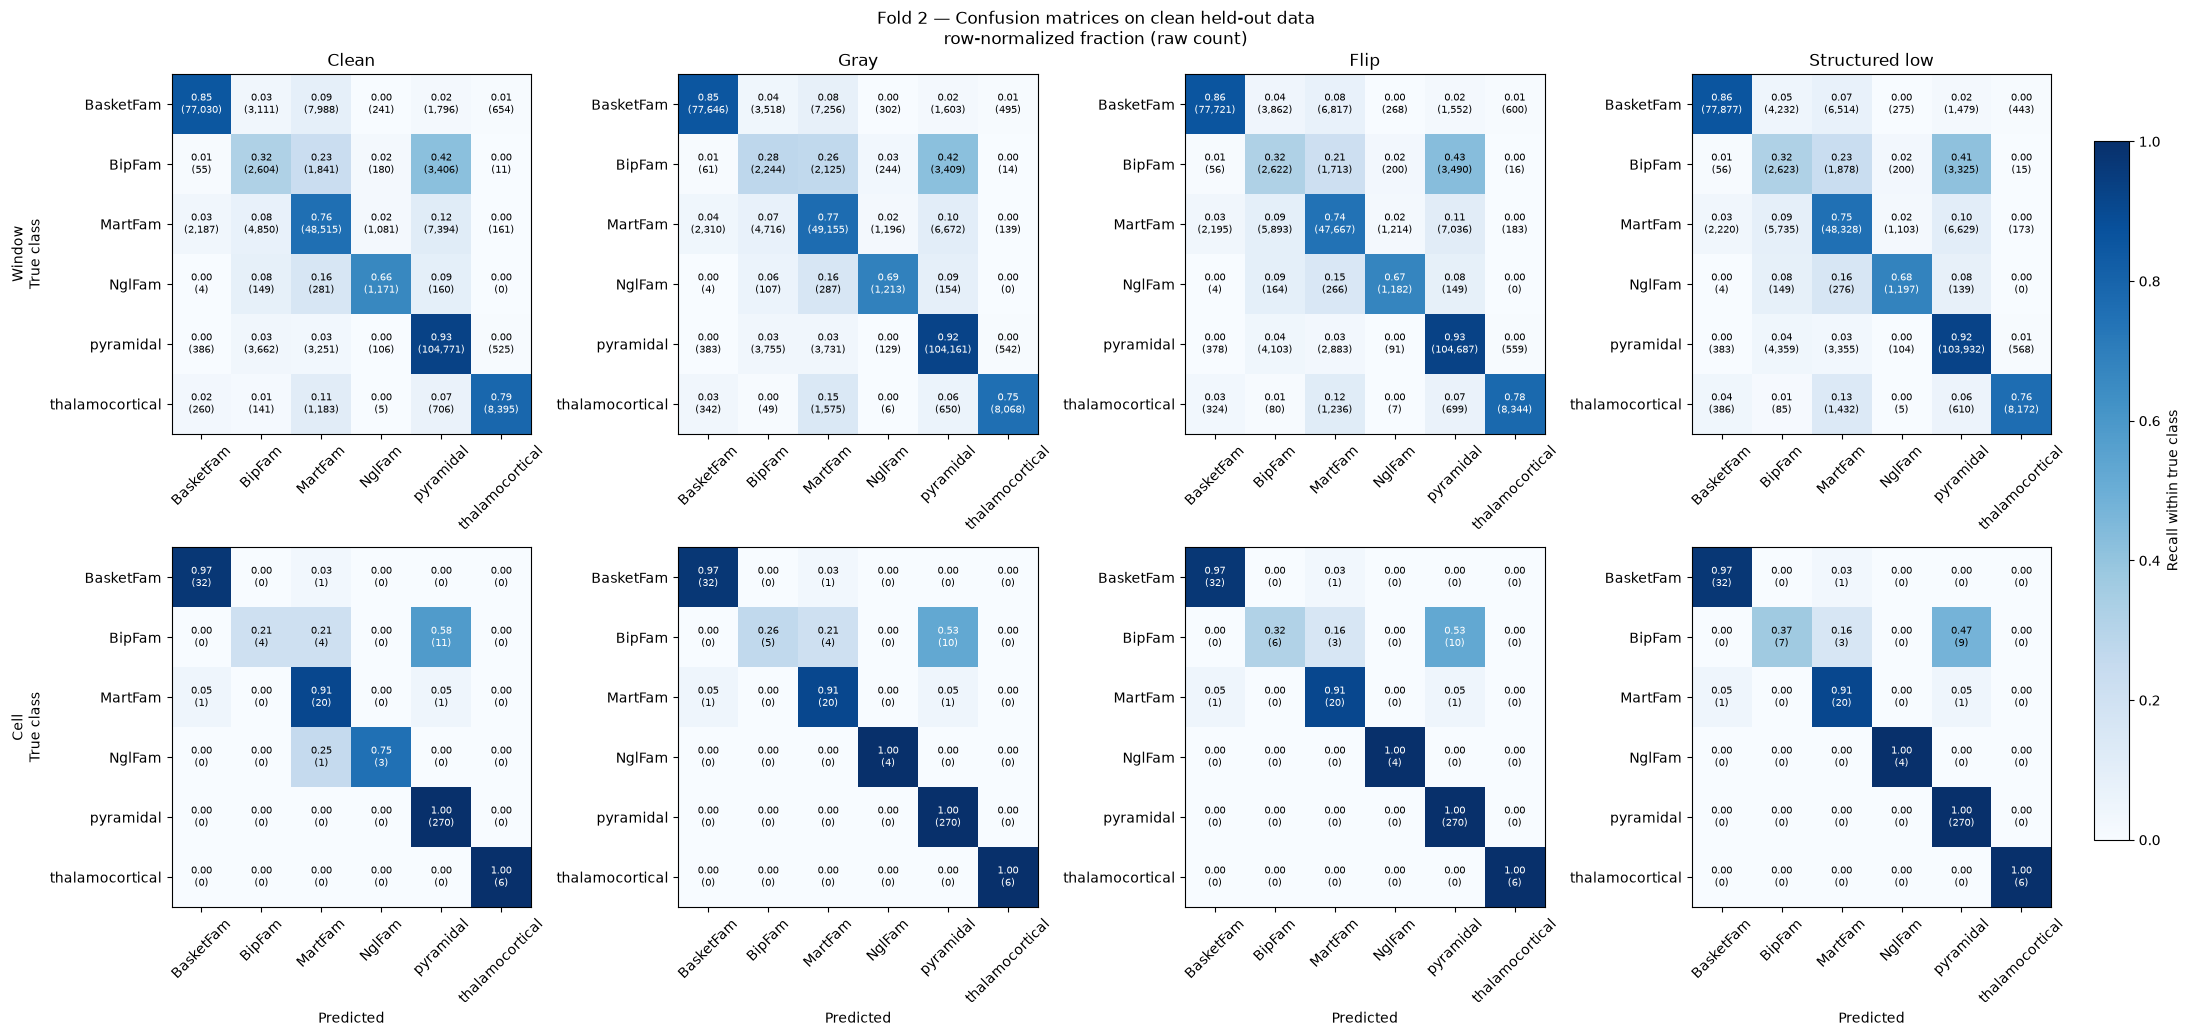

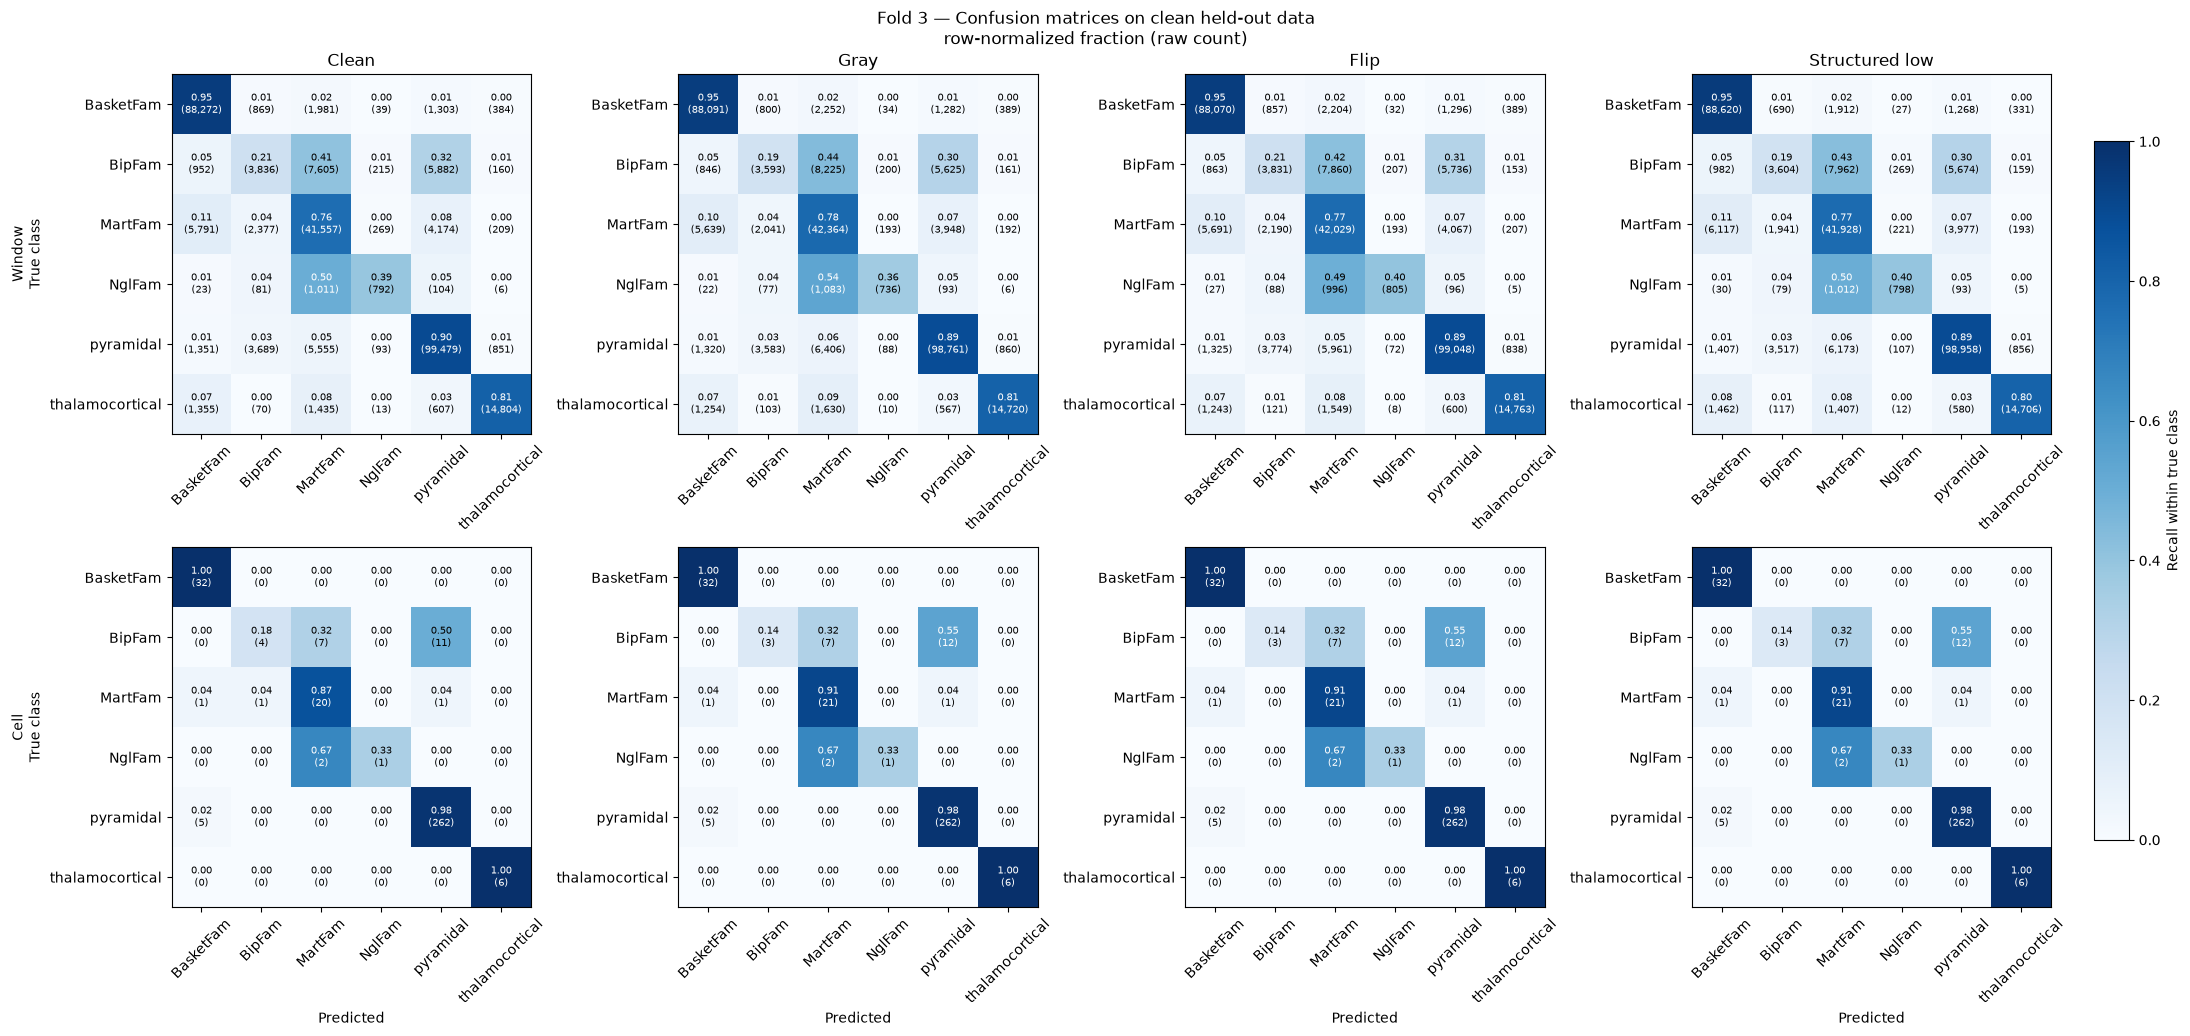

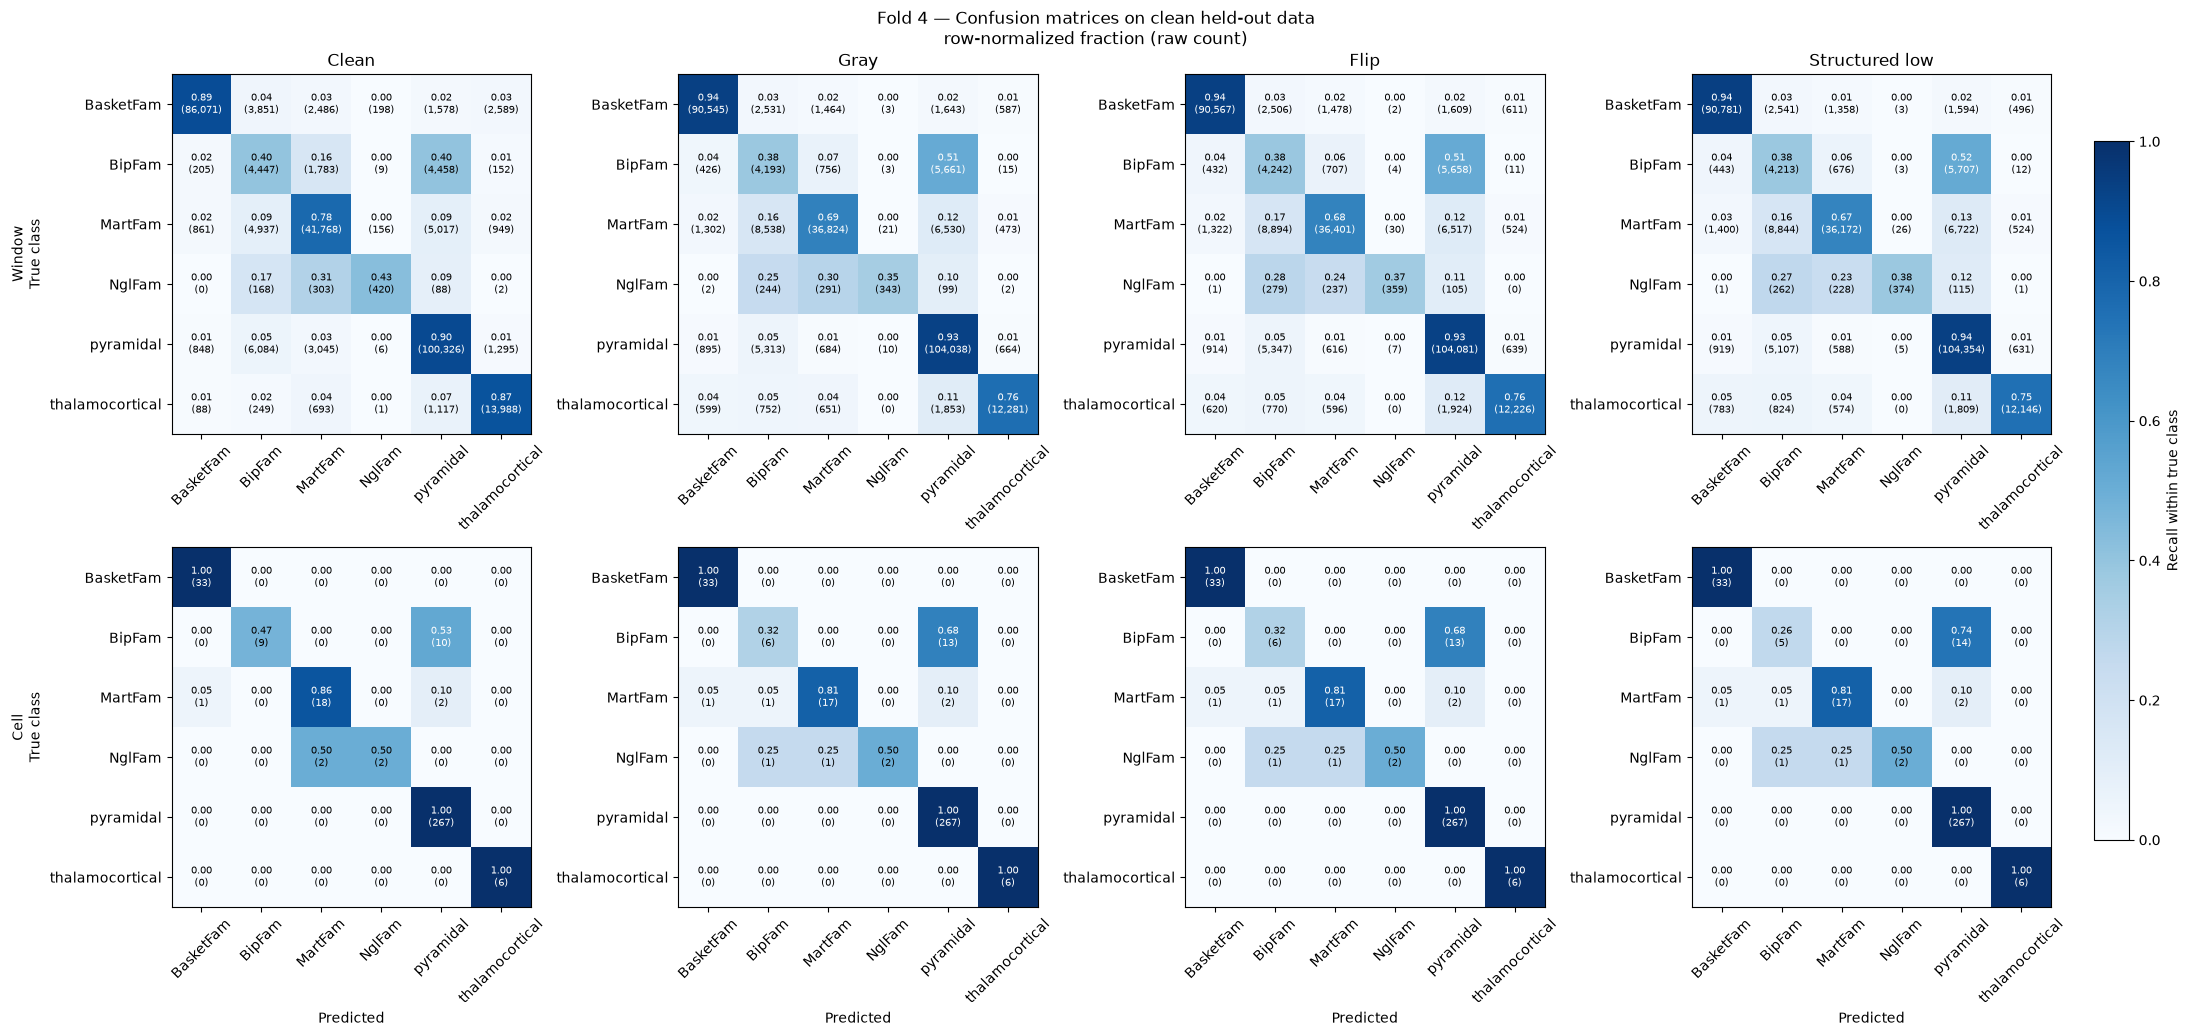

In [6]:
for fold, fold_payloads in sorted(payloads_by_fold.items()):
    show_fold_figure(plot_confusions(fold_payloads, normalize=True), fold)


## How augmentation propagates through the clean-trained model

Paired comparison on 24,000 class-balanced training windows. The same clean-trained checkpoint receives clean and augmented versions of each window.

In [7]:
import json
import pandas as pd
propagation_path = ROOT / "analysis/presynaptic/cave_embedding_augmentation_conf0.7/augmentation_propagation.json"
propagation = json.loads(propagation_path.read_text())
rows = []
for policy, values in propagation["policies"].items():
    rows.append({
        "augmentation": policy,
        "node cosine": values["node_cosine"]["mean"],
        "mean-pooled cosine": values["mean_cosine"]["mean"],
        "GT cosine": values["gt_cosine"]["mean"],
        "classifier-trunk cosine": values["trunk_cosine"]["mean"],
        "prediction agreement": values["prediction_agreement"],
        "accuracy change": values["augmented_window_accuracy"] - values["clean_window_accuracy"],
        "wrong→correct": values["wrong_to_correct"],
        "correct→wrong": values["correct_to_wrong"],
    })
display(pd.DataFrame(rows).set_index("augmentation"))

,node cosine,mean-pooled cosine,GT cosine,classifier-trunk cosine,prediction agreement,accuracy change,wrong→correct,correct→wrong
augmentation,,,,,,,,
gray,0.982776,0.997165,0.986580,0.988601,0.938583,-0.003375,538,619
flip,0.980637,0.996918,0.980000,0.982707,0.922542,0.003458,775,692
structured_low,0.999000,0.999623,0.997979,0.998207,0.974625,0.002125,270,219
